# Оценка качества классификации

**Задача классификации** - это задача разделения объектов на классы по известным признакам объектов. Алгоритмы классификации применяются, например:

- в спам-фильтрах
- при диагностике заболеваний (прогнозирование)
- при оценке платёжеспособности кандидатов на получение кредитов (прогнозирование)
- при распознавании рукописных букв и цифр (распознавание образов)
- при анализе тональности отзывов (классификация текстов)

Как и в случае регрессии, в задачах классификации требуется оценивать качество обученной модели. Для этого существуют несколько метрик.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

## Confusion matrix (матрица ошибок)

Если представить сочетание ответов алгоритма и истинных ответов в виде таблицы, то получится **матрица ошибок**.

|  <empty>   | $$y = +1$$ | $$y = -1$$ |
--- | --- | ---
| __$$\hat y = +1$$__  |   $$TP$$    |   $$FP$$   |
| __$$\hat y = -1$$__ |   $$FN$$    |   $$TN$$  |
    
В матрице сверху расположены истинные ответы, слева — ответы алгоритма. Если алгоритм дал объекту положительный класс, и объект действительно относится к классу «+1», то это **верный положительный ответ (True Positive, TP)**.

Если алгоритм дал объекту положительный класс, а объект на самом деле отрицательного класса, то это ошибка - **ложное срабатывание (False Positive, FP)**.

Когда алгоритм дает объекту отрицательный класс, а его истинный класс положительный, то это тоже ошибка - **ложный пропуск (False Negative, FN)**.

Если истинный класс объекта «-1», и алгоритм дает этому объекту отрицательный класс, то это **верный отрицательный ответ (True Negative, TN)**.

При такой классификации разделяем все ошибки на два вида — ложные срабатывания и ложные пропуски. По главной диагонали в матрице ошибок располагаются верные ответы, по побочной — ошибки.    

**Пример**

In [2]:
y =    np.array([1, 1, 1, 1, 0, 1, 0, 0, 1, 0]) # истинный класс
pred = np.array([1, 1, 1, 0, 0, 0, 1, 0, 1, 0]) # предсказанный класс
print('true =', y)
print('pred =', pred)

true = [1 1 1 1 0 1 0 0 1 0]
pred = [1 1 1 0 0 0 1 0 1 0]


Матрица ошибок:

|  <empty>   | $$y = 1$$ | $$y = 0$$ |
--- | --- | ---
| __$$\hat y = 1$$__  |   $$4$$    |   $$1$$   |
| __$$\hat y = 0$$__ |   $$2$$    |   $$3$$   |
    

### Accuracy (точность)

Самый простой и логичный способ оценить точность модели - посчитать *долю правильных ответов*:
$$accuracy=\frac{1}{n}\sum^n_{i=1}[\hat y_i == y_i],$$

где $\hat y$ - предсказанный класс; $y$ - истинный класс.

Если использовать матрицу ошибок, то формула будет такой:

$$accuracy=\frac{TP+TN}{TP+TN+FP+FN}$$

Однако у этой метрики есть недостаток: она бесполезна в случае *дисбаланса классов* (когда объектов одного класса значительно меньше, чем другого). Например, у нас есть выборка с 950 объектами класса «1» и 50 объектами класса «0». Мы делаем прогноз: всем присваиваем первый класс. Доля правильных ответов в этом случае составит 0.95 (что довольно много), но такой прогноз на самом деле абсолютно бесполезный.

In [3]:
accuracy = (y == pred).mean()
print(f'Accuracy = {accuracy}')

Accuracy = 0.7


### Precision (точность) и recall (полнота)

Для оценки качества работы алгоритма на каждом из классов по отдельности используются метрики **precision** (точность) и **recall** (полнота).

Precision представляет собой долю объектов, названных алгоритмом положительными и при этом действительно являющимися положительными:

$$precision = \frac{TP}{TP+FP}$$

Recall показывает, какую долю объектов положительного класса из всех объектов положительного класса нашел алгоритм:

$$recall = \frac{TP}{TP+FN}$$

Precision и recall не зависят, в отличие от accuracy, от соотношения классов и потому применимы в условиях несбалансированных выборок.

Часто стоит задача найти оптимальный баланс между этими двумя метриками.


**Пример**

Матрица ошибок:

|  <empty>   | $$y = 1$$ | $$y = 0$$ |
--- | --- | ---
| __$$\hat y = 1$$__  |   $$4$$    |   $$1$$   |
| __$$\hat y = 0$$__ |   $$2$$    |   $$3$$   |

In [4]:
# вариант заполнения матрицы ошибок
cmatrix = np.zeros((2, 2))
for i in range(len(y)):
    cmatrix[~y[i]][~pred[i]] += 1
cmatrix = cmatrix.astype(int).T
print(cmatrix)

[[4 1]
 [2 3]]


In [5]:
TP = 4
FP = 1 # ложное срабатывание
FN = 2 # пропуск
TN = 3

In [6]:
print(f'Accuracy = \t{(TP+TN)/(TP+TN+FP+FN):.2f}')
print(f'Precision = \t{TP/(TP+FP):.2f}')
print(f'Recall = \t{TP/(TP+FN):.2f}')

Accuracy = 	0.70
Precision = 	0.80
Recall = 	0.67


### F-score (F-мера)

Обычно при оптимизации гиперпараметров алгоритма используется одна метрика. Существует несколько различных способов объединить precision и recall в агрегированный критерий качества. **F-мера** — среднее гармоническое precision и recall:

$$F = \frac{2 \cdot precision \cdot recall }{ precision + recall}$$

F-мера достигает максимума при precision и recall, равными единице, и близка к нулю, если один из аргументов близок к нулю.

Важно: на величину метрик accuracy, precision, recall и f-меры **влияет порог вероятности**.

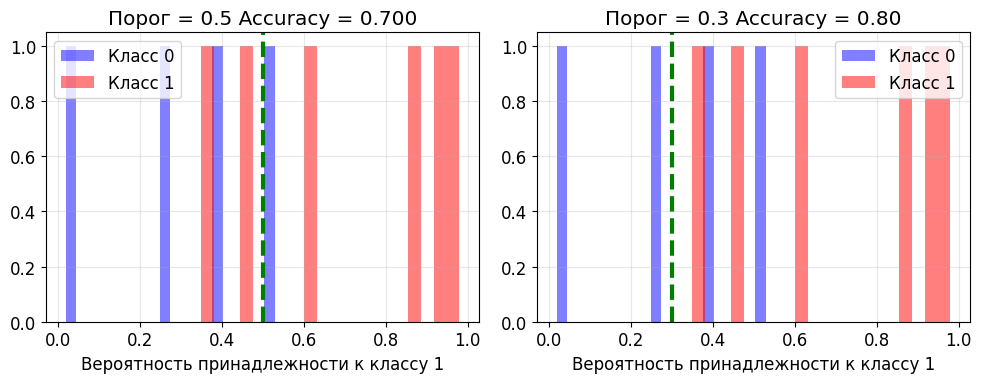

In [7]:
y = np.array([1, 1, 1, 1, 0, 1, 0, 0, 1, 0]) # истинный класс
prob = np.array([0.98, 0.86, 0.62, 0.35, 0.25, 0.45, 0.53, 0.02, 0.92, 0.38])
pred1 = np.where(prob > 0.5, 1, 0)
pred2 = np.where(prob > 0.3, 1, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# порог = 0.5
ax1.hist(prob[y==0], bins=20, alpha=0.5, label='Класс 0', color='blue', density=False)
ax1.hist(prob[y==1], bins=20, alpha=0.5, label='Класс 1', color='red', density=False)
ax1.axvline(x=0.5, color='green', linestyle='--', lw=3)
ax1.set_xlabel('Вероятность принадлежности к классу 1')
ax1.set_title(f'Порог = 0.5 Accuracy = {(y == pred1).mean():.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# порог = 0.3
ax2.hist(prob[y==0], bins=20, alpha=0.5, label='Класс 0', color='blue', density=False)
ax2.hist(prob[y==1], bins=20, alpha=0.5, label='Класс 1', color='red', density=False)
ax2.axvline(x=0.3, color='green', linestyle='--', lw=3)
ax2.set_xlabel('Вероятность принадлежности к классу 1')
ax2.set_title(f'Порог = 0.3 Accuracy = {(y == pred2).mean():.2f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ROC AUC (площадь под кривой ошибок)

Одним из способов оценить модель в целом, не привязываясь к конкретному порогу, является **ROC AUC**. ROC-кривая (Receiver Operating Characteristic curve) представляет из себя линию от (0,0) до (1,1) в координатах True Positive Rate (TPR) и False Positive Rate (FPR):

$$FPR = \frac{FP}{FP+TN}$$

$$TPR = \frac{TP}{TP+FN}$$

False Positive Rate - отношение числа ложных срабатываний к общему размеру отрицательного класса, а True Positive Rate - отношение числа верных срабатываний к размеру положительного класса (recall).

Построим ROC-кривую.






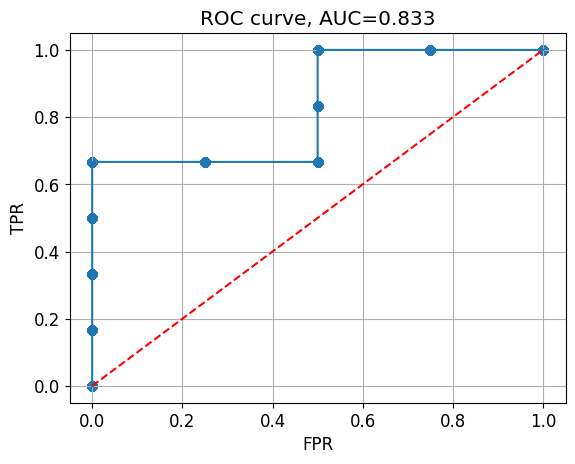

In [8]:
from numpy import trapezoid  # используем эту функцию для расчёта площади под кривой

# предсказанные вероятности отнесения объектов в первому классу:
prob = np.array([0.98, 0.86, 0.62, 0.42, 0.25, 0.43, 0.51, 0.02, 0.92, 0.48])
TPR = [] # доля верных срабатываний (True Positive Rate)
FPR = [] # доля ложных срабатываний (False Positive Rate)

for threshold in np.arange(0, 1.01, 0.0001):
    pred = np.where(prob > threshold, 1, 0)
    cmatrix = np.zeros((2, 2))
    for i in range(len(y)):
        cmatrix[~y[i]][~pred[i]] += 1
    cmatrix = cmatrix.astype(int).T # [[TP, FP], [FN, TN]]
    TPR.append(cmatrix[0][0] / (cmatrix[0][0] + cmatrix[1][0])) # TP / (TP + FN)
    FPR.append(cmatrix[0][1] / (cmatrix[0][1] + cmatrix[1][1])) # FP / (FP + TN)

AUC = -1 * np.trapezoid(TPR, FPR)

plt.title(f'ROC curve, AUC={AUC:.3f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.grid()
plt.scatter(FPR, TPR)
plt.plot(FPR, TPR)
plt.plot([0, 1], [0, 1], color='r', linestyle='--');

In [9]:
d = np.zeros((10, 2))
d[:, 0] = prob
d[:, 1] = y
d[d[:, 0].argsort()[::-1]]

array([[0.98, 1.  ],
       [0.92, 1.  ],
       [0.86, 1.  ],
       [0.62, 1.  ],
       [0.51, 0.  ],
       [0.48, 0.  ],
       [0.43, 1.  ],
       [0.42, 1.  ],
       [0.25, 0.  ],
       [0.02, 0.  ]])

### Метрики из библиотеки scikit-learn

В модуле sklearn.metrics реализованы следующие функции оценки качества прогноза:

- classification_report(y_true, y_pred)
- confusion_matrix(y_true, y_pred)
- accuracy_score(y_true, y_pred)
- precision_score(y_true, y_pred)
- recall_score(y_true, y_pred)
- f1_score(y_true, y_pred)
- roc_auc_score(y_true, y_score)
- roc_curve(y_true, y_score)

In [36]:
y =    np.array([1, 1, 1, 1, 0, 1, 0, 0, 1, 0]) # истинный класс
pred = np.array([1, 1, 1, 0, 0, 0, 1, 0, 1, 0]) # предсказанный класс

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y, pred))

              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.80      0.67      0.73         6

    accuracy                           0.70        10
   macro avg       0.70      0.71      0.70        10
weighted avg       0.72      0.70      0.70        10



[[3 1]
 [2 4]]


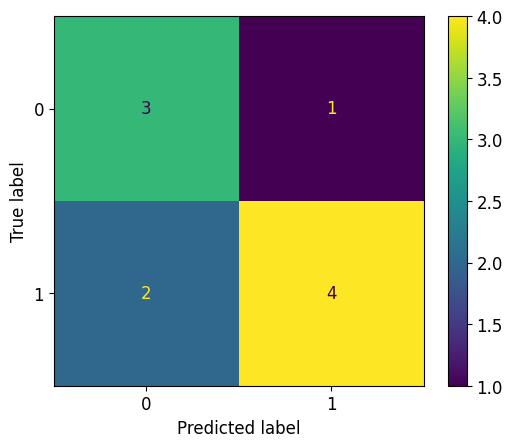

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y, pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f'Accuracy = \t{accuracy_score(y, pred):.2f}')
print(f'Precision = \t{precision_score(y, pred):.2f}')
print(f'Recall = \t{recall_score(y, pred):.2f}')
print(f'F1-score = \t{f1_score(y, pred):.2f}')

Accuracy = 	0.70
Precision = 	0.80
Recall = 	0.67
F1-score = 	0.73


In [38]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y, prob).round(2))

0.83


## 2. Многоклассовая классификация

Бинарный классификатор выдает один из двух классов (0 или 1) либо вероятности отнесения объектов к этим двум классам. Но как построить линейную модель, способную разделять объекты на несколько классов и как оценить точность такой модели?

Существуют несколько подходов к решению задачи многоклассовой классификации.

Первый подход называется **"один против всех" - OvA или OvR** (one-vs-all  или one-vs-rest). Допустим, у нас есть 4 класса. Идея состоит в том, чтобы построить 4 бинарных классификатора, каждый из которых будет отделять один класс от всех остальных. После того, как классификаторы после обучения выдали вероятности отнесения к каждому классу, находим максимальную вероятность и соответствующий ей класс возвращаем в качестве ответа.

Второй подход называется **"один против каждого" - OvO** (one-vs-one). Обучаем бинарные классификаторы для каждой пары классов. Если у нас 4 класса, нам потребуется построить 6 классификатора. А если у нас 10 классов, то таких классификаторов потребуется 45 штук. "Один против каждого" обучает бОльшее число классификаторов, однако каждый из них обучается на небольшой подвыборке (объекты только двух классов).

<img src='https://drive.google.com/uc?id=1IsrMzPttawLgDaDkqYD4RUHNFPhVMfoH' width=1000 align='center'></img>

Посмотрим многоклассовую классификацию на примере логистической регрессии, реализованной в библиотеке sklearn.

## Пример классификации рукописных цифр

In [15]:
from sklearn.datasets import load_digits

digits = load_digits()
digits.data.shape, digits.target.shape, digits.images.shape

((1797, 64), (1797,), (1797, 8, 8))

In [16]:
digits.target[:100]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1,
       2, 3, 4, 5, 6, 7, 8, 9, 0, 9, 5, 5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7,
       7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2, 0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6,
       6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8, 2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4,
       6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3, 1])

In [17]:
digits.data[1].reshape(8,8)

array([[ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16.,  9.,  0.,  0.],
       [ 0.,  0.,  3., 15., 16.,  6.,  0.,  0.],
       [ 0.,  7., 15., 16., 16.,  2.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  3.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16., 10.,  0.,  0.]])

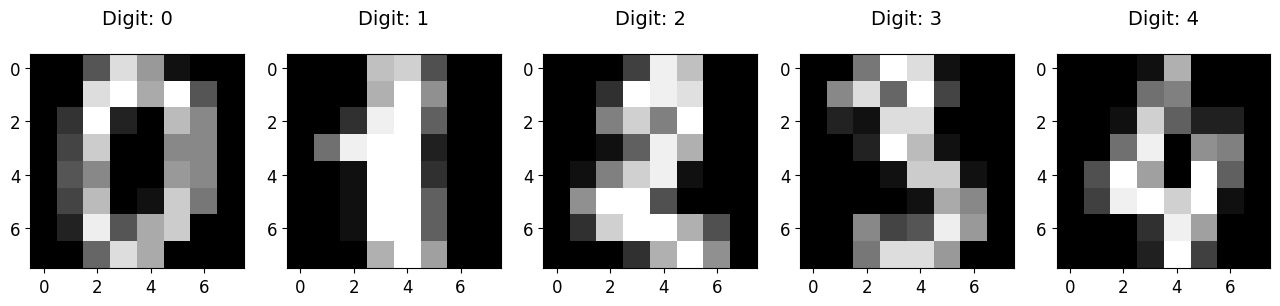

In [39]:
plt.figure(figsize=(16,4))
for index, (image, label) in enumerate(zip(digits.data[0:5],
                                           digits.target[0:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
    plt.title('Digit: %i\n' % label, fontsize = 14);

Разобьем данные на две части:

- тренировочный набор данных (признаки в X_train, целевая переменная в y_train)

- и валидационный (соответственно X_valid и y_valid).

На тренировочном датасете мы будем строить модель, а на валидационном - проверять её качество.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(digits.data,
                                                    digits.target,
                                                    test_size=0.25,
                                                    random_state=42)
X_train.shape, X_valid.shape

((1347, 64), (450, 64))

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(fit_intercept=True,
                        solver='saga',
                        max_iter=10000,
                        C=100)
model

LogisticRegression(C=100, max_iter=10000, solver='saga')

In [21]:
model.fit(X_train, y_train)

LogisticRegression(C=100, max_iter=10000, solver='saga')

In [22]:
model.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [23]:
model.coef_[1].reshape(8,8).round(2)

array([[ 0.  ,  0.  , -0.21,  0.18, -0.84,  0.51, -0.01, -0.02],
       [-0.  , -0.4 , -0.36, -0.38,  0.34, -0.14, -0.36, -0.03],
       [ 0.1 ,  0.31, -0.07,  0.7 ,  0.17, -0.2 , -0.01, -0.  ],
       [ 0.03, -0.12, -0.04,  0.07,  0.3 ,  0.1 , -0.09, -0.  ],
       [ 0.  , -0.15,  0.18, -0.15,  0.16,  0.2 , -0.13,  0.  ],
       [-0.  , -0.19,  0.14,  0.39, -0.05, -0.17, -0.62, -0.  ],
       [-0.  , -0.24, -0.15,  0.17,  0.28, -0.07, -0.25,  0.24],
       [-0.  ,  0.01, -0.25, -0.05,  0.16,  0.23,  0.15,  0.23]])

Представим коэффициенты визуально.

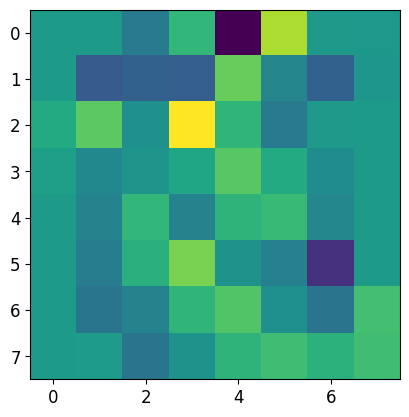

In [24]:
coef = model.coef_.copy()
plt.imshow(coef[1].reshape(8,8).round(2));

In [25]:
y_pred = model.predict(X_valid)
print(y_pred[0:9])
print(y_valid[0:9])

[6 9 3 7 2 1 5 2 5]
[6 9 3 7 2 1 5 2 5]


In [26]:
model.score(X_valid, y_valid)

0.9733333333333334

In [27]:
# from sklearn import metrics
cm = confusion_matrix(y_true=y_valid, y_pred=y_pred,
                 labels=model.classes_)
cm

array([[43,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 36,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 38,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 44,  0,  1,  0,  0,  1,  0],
       [ 0,  1,  0,  0, 53,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 57,  1,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  1, 44,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 40,  0,  1],
       [ 0,  0,  0,  0,  0,  1,  0,  0, 37,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  1, 46]])

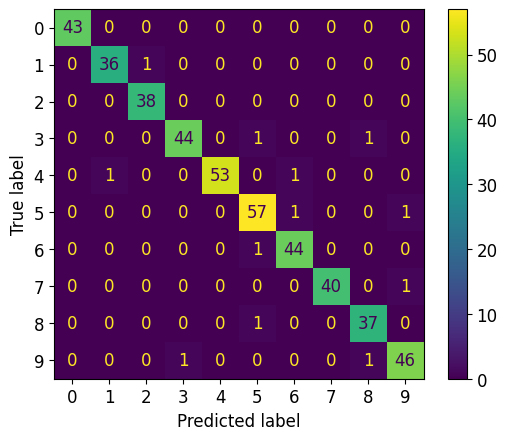

In [28]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

In [29]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       0.97      0.97      0.97        37
           2       0.97      1.00      0.99        38
           3       0.98      0.96      0.97        46
           4       1.00      0.96      0.98        55
           5       0.95      0.97      0.96        59
           6       0.96      0.98      0.97        45
           7       1.00      0.98      0.99        41
           8       0.95      0.97      0.96        38
           9       0.96      0.96      0.96        48

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



## Источники

[Метрики scikit-learn](https://scikit-learn.ru/3-3-metrics-and-scoring-quantifying-the-quality-of-predictions/)

[Recognizing hand-written digits](https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html)

## Задания

1. Загрузить датасет iris. Разбить данные на обучающую выборку и валидационную. Обучить логистическую регрессию на обучающей выборке, проверить на валидационной разными метриками. Сделать вывод (6 баллов)

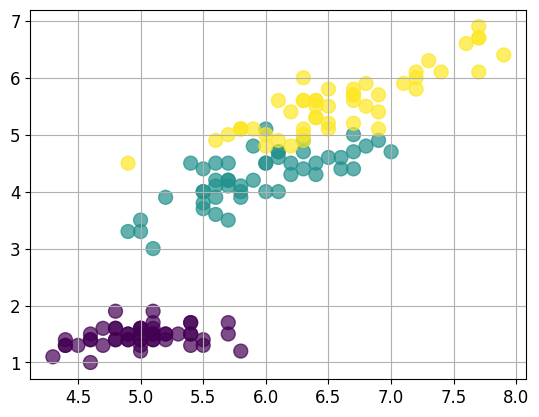

In [30]:
from sklearn.datasets import load_iris

iris_dataset = load_iris()
X = iris_dataset.data
y = iris_dataset.target

plt.scatter(X.T[0], X.T[2],
            alpha=0.7, s=100, c=iris_dataset.target)
plt.grid();

In [31]:
X[:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [32]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [33]:
# не забудьте разбить датасет на тренировочные и тестовые данные
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25,
                                                      random_state=0)


In [34]:
#